In [ ]:
import pandas as pd
import numpy as np
import importlib
from tqdm import tqdm

from sklearn.metrics import silhouette_score

import networkx as nx
import community as community_louvain

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [4]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv", index_col=[0, 1])

In [5]:
df_cutoff = (
    pd.DataFrame({}, index=df_cs_yearly.index)
    .assign(
        total = df_cs_yearly.sum(axis=1),
        cutoff_5000 = lambda df: (df.total >= 5000).astype(int),
        cutoff_1000 = lambda df: (df.total >= 1000).astype(int),
    )
)

In [34]:
year = 2020

cutoff = 2000
param = "total"

country_idx = df_cutoff.xs(year, level=1).query(param+f" >= @cutoff").index.to_list()
df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]


df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_dist = df_dist_yearly.xs(year, level=1).loc[country_idx, country_idx]

np.fill_diagonal(df_dist.values, np.nan)

In [35]:
df_cs_example = df_cs
df_example = df_dist

In [36]:
D = df_example.fillna(0).values

similarity = 1 / (1 + D)

G = nx.from_numpy_array(similarity)

np.random.seed(0)

partition = community_louvain.best_partition(G, weight="weight")
labels = np.array(list(partition.values()))
df_map = (
    pd.DataFrame(labels, index=df_example.index, columns=["cluster"])
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2")
    .merge(df_cs_example.sum(axis=1).to_frame("total_articles"), left_on="alpha-2", right_index=True)
)

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, list(labels), metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_example, labels))

Clusters: 
0    33
3    30
2    26
1    18
Name: count, dtype: int64

Silhouette Score:  0.2484222418966502
Dunn Index:  0.08672588363923961


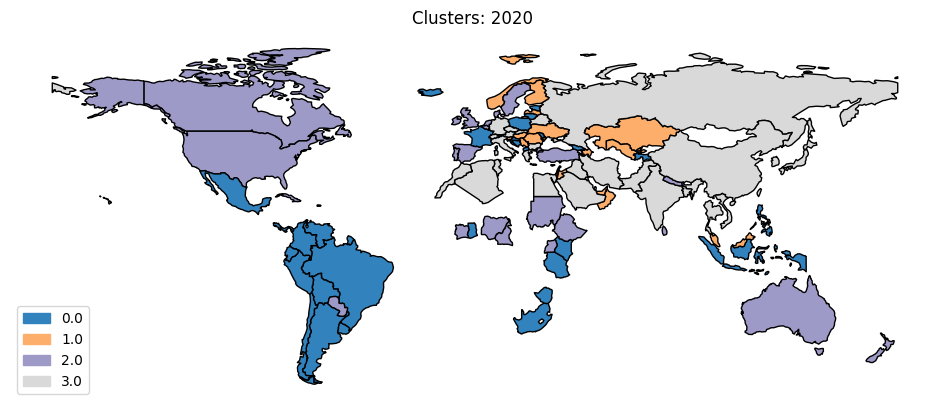

In [37]:
_, _ = uf.plot_map_discrete(df_map, "cluster", country_column="alpha-3", title=f"Clusters: {year}")